Hello students! This week task involves training and evaluating a Flow model for the generation task.

**LOAD LIBRARIES**

In [20]:
import sklearn
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn

**LOAD DATASET**

In [21]:
#Load Toy dataset
class DatasetMoons(object):
    def sample(self, n):
        moons = sklearn.datasets.make_moons(n_samples=n, noise=0.05)[0].astype(np.float32)
        return torch.from_numpy(moons)

Now ! we implement Normalizing flow model called RealNVP. More about the normalizing flows can be learnt at https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial11/NF_image_modeling.html

**Coupling Layer**

In [22]:
class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim, parity):
        super(CouplingLayer, self).__init__()
        self.dim = dim
        self.parity = parity
        self.scale = nn.Sequential(nn.Linear(dim//2, hidden_dim),
                                   nn.LeakyReLU(),
                                   nn.Linear(hidden_dim, dim//2))
        self.translate = nn.Sequential(nn.Linear(dim//2, hidden_dim),
                                   nn.LeakyReLU(),
                                   nn.Linear(hidden_dim, dim//2))

    def forward(self, x):
        x0, x1 = x[:, ::2], x[:, 1::2]
        if self.parity:
            x0, x1 = x1, x0
        z0 = x0
        s = self.scale(x0)
        t = self.translate(x0)
        z1 = torch.exp(s) * x1 + t
        if self.parity:
            z0, z1 = z1, z0
        z = torch.cat([z0, z1], dim=1)
        log_det = torch.sum(s, dim=1)

        return z, log_det

    def backward(self, z):
        z0, z1 = z[:, ::2], z[:, 1::2]
        if self.parity:
            z0, z1 = z1, z0
        x0 = z0
        s = self.scale(z0)
        t = self.translate(z0)
        x1 = (z1 - t) * torch.exp(-s)
        if self.parity:
            x0, x1 = x1, x0
        x = torch.cat([x0, x1], dim=1)
        log_det = torch.sum(-s, dim=1)

        return x, log_det

**Normalizing Flow Block**

In [23]:
class NormalizingFlow(nn.Module):
    def __init__(self, flows):
        super(NormalizingFlow, self).__init__()
        self.flows = nn.ModuleList(flows)

    def forward(self, x):
        batch_size = x.size(0)
        log_det = torch.zeros(batch_size).to(x.device)
        zs = [x]
        for flow in self.flows:
            x, ld = flow.forward(x)
            log_det += ld
            zs.append(x)
        return zs, log_det

    def backward(self, z):
        batch_size = z.size(0)
        log_det = torch.zeros(batch_size).to(z.device)
        xs = [z]
        for flow in self.flows[::-1]:
            z, ld = flow.backward(z)
            log_det += ld
            xs.append(z)
        return xs[-1], log_det

**Flow Model**

In [24]:
class NormalizingFlowModel(nn.Module):
    def __init__(self, prior, flows):
        super(NormalizingFlowModel, self).__init__()
        self.prior = prior
        self.flow = NormalizingFlow(flows)

    def forward(self, x):
        zs, log_det = self.flow.forward(x)
        prior_log_prob = self.prior.log_prob(zs[-1])
        
        return zs, prior_log_prob, log_det

    def backward(self, z):
        xs, log_det = self.flow.backward(z)
        return xs, log_det

    def sample(self, num_samples):
        device = next(self.flow.parameters())
        z = self.prior.sample((num_samples,)).to(device)
        xs, _ = self.flow.backward(z)
        return xs

In [25]:
import matplotlib.pyplot as plt

def plot_x_z_prior(x, z, prior_samples):
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed

    plt.scatter(x[:, 0].cpu().numpy(), x[:, 1].cpu().numpy(), label="Original x", alpha=0.6, color='blue')
    plt.scatter(z[:, 0].cpu().numpy(), z[:, 1].cpu().numpy(), label="Latent z", alpha=0.6, color='green')
    plt.scatter(prior_samples[:, 0].cpu().numpy(), prior_samples[:, 1].cpu().numpy(), label="Prior Samples", alpha=0.6, color='red')

    plt.title("Original Data (x), Latent Space (z), and Prior Samples")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_x_reconstructed(x, x_reconstructed, z):
    plt.figure(figsize=(8, 6))
    plt.scatter(x[:, 0].cpu().numpy(), x[:, 1].cpu().numpy(), label="Original x", alpha=0.6, color='blue')
    plt.scatter(x_reconstructed[:, 0].cpu().numpy(), x_reconstructed[:, 1].cpu().numpy(), label="Reconstructed x", alpha=0.6, color='orange')
    plt.scatter(z[:, 0].cpu().numpy(), z[:, 1].cpu().numpy(), label="Latent z", alpha=0.6, color='green')
    plt.title("Original x, Reconstructed x, and Latent z")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.show()


**Train the Model**

346.2465515136719
207.56251525878906
182.32406616210938
169.04115295410156
163.76528930664062
147.556396484375
149.1236572265625
128.53395080566406
150.599365234375
133.0311279296875
120.59870910644531
114.06324768066406
118.64969635009766
181.21029663085938
128.8216552734375
123.7260513305664
114.79297637939453
114.32308959960938
108.25688171386719
117.70182800292969
119.88345336914062
120.18046569824219
110.59251403808594
119.55194854736328
115.88345336914062
116.043212890625
114.07876586914062
116.16608428955078
107.87298583984375
105.42912292480469
118.67669677734375


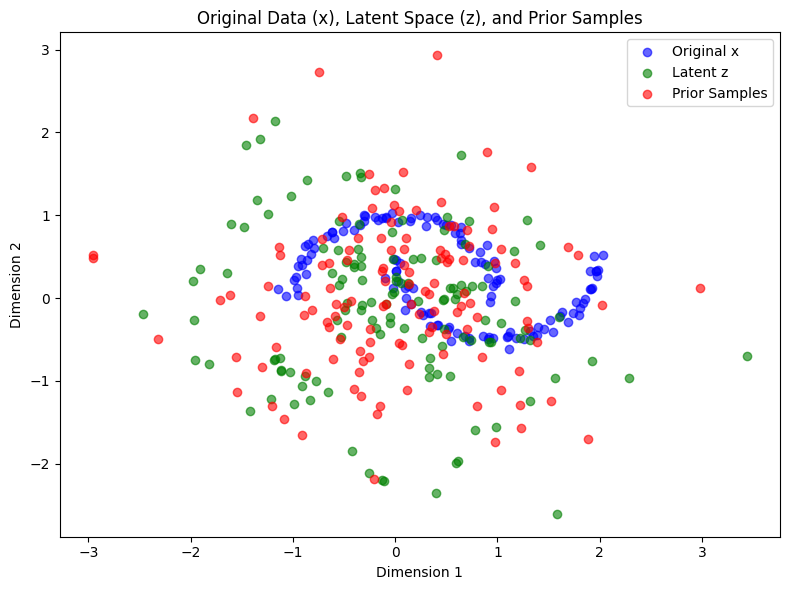

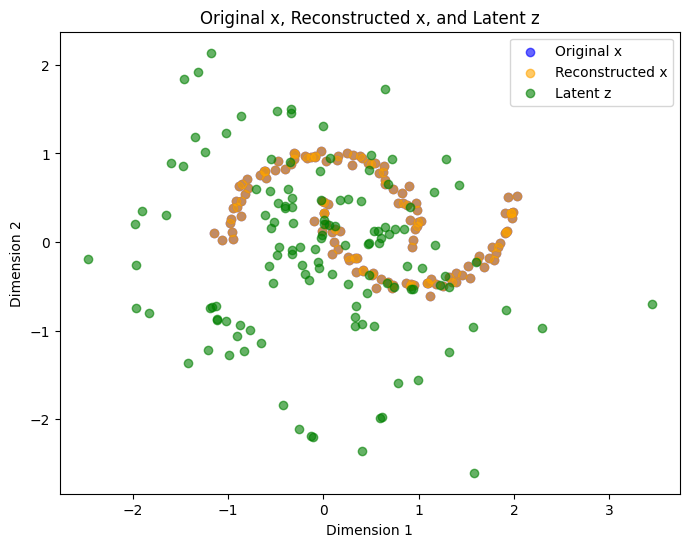

In [26]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import datasets
from torch.distributions import MultivariateNormal
from torchvision import datasets, transforms


epochs = 3000
batch_size = 128
lr = 1e-3
num_blocks = 5
input_dim = 2
max_grad_norm = 5
hidden_dim = 24
def main():
    device = 'cpu'
    prior = MultivariateNormal(torch.zeros(2).to(device),
                               torch.eye(2).to(device))
    d = DatasetMoons()

    flows = [CouplingLayer(input_dim, hidden_dim, parity=i % 2)
             for i in range(num_blocks)]
    model = NormalizingFlowModel(prior, flows)
    optimizer = optim.Adam(model.parameters(), lr)
    model = model.to(device)
    model.train()
    
    for epoch in range(0, epochs+1):
        x = d.sample(batch_size)
        x = x.to(device)
        zs, prior_logprob, log_det = model(x)
        logprob = prior_logprob + log_det
        loss = -torch.sum(logprob)

        model.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(loss.item())
    model.eval()
    x = d.sample(128)
    x = x.to(device)
    with torch.no_grad():
        zs, prior_logprob, log_det = model(x)
    z = zs[-1]
    with torch.no_grad():
        x_reconstructed, _ = model.backward(z)
    # Plot x, z, and prior in one figure
    prior_samples = prior.sample((128,))
    plot_x_z_prior(x, z, prior_samples)
    # Plot x and reconstructed x in one figure
    plot_x_reconstructed(x, x_reconstructed, z)
main()

**TO DOs We focus on**

1. Explain the architecture of RealNVP flow model above and also write about normalizing flow model in general.

2. Train the above setup and also generate the data by sampling from the learnt latent space z.

3. plot x->z and z->x  process of the flow model during inference. 

4. Improve the complexity of flows in the network and train & evaluate the modified network for generation task and plot the results.
NOTE: complexity of flows includes increase the layers in flow block or increasing the number of blocks itself.